In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [2]:
fund = pd.read_csv("../data/processed/scheme_performance_clean.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
txn = pd.read_csv("../data/processed/investor_transactions_clean.csv")

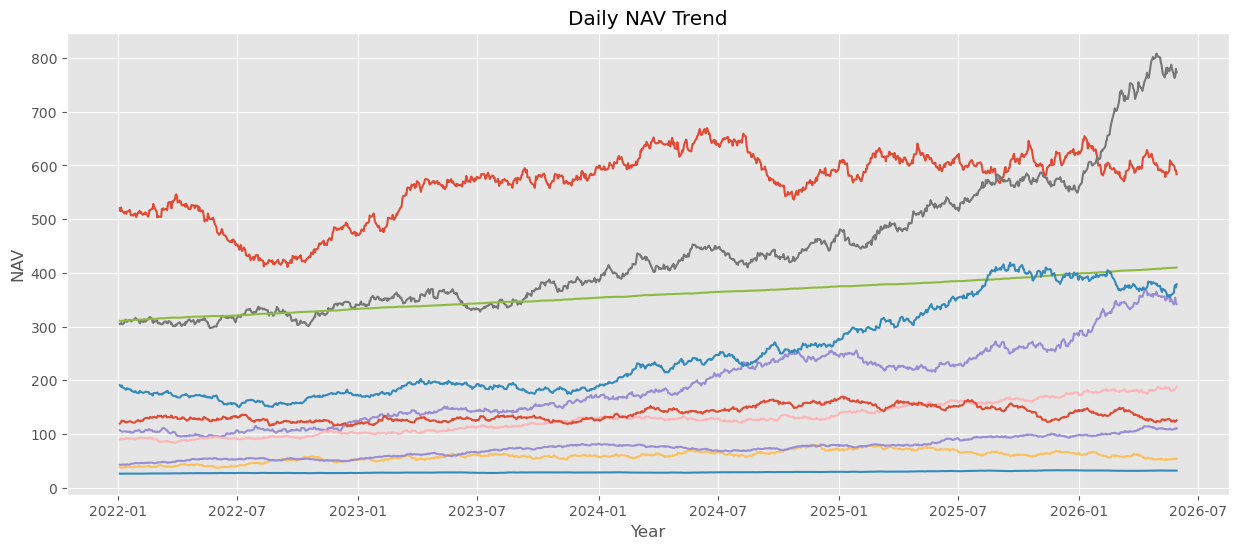

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(15,6))

for code in nav["amfi_code"].unique()[:10]:
    data = nav[nav["amfi_code"]==code]
    plt.plot(data["date"],data["nav"])

plt.title("Daily NAV Trend")
plt.xlabel("Year")
plt.ylabel("NAV")
plt.show()

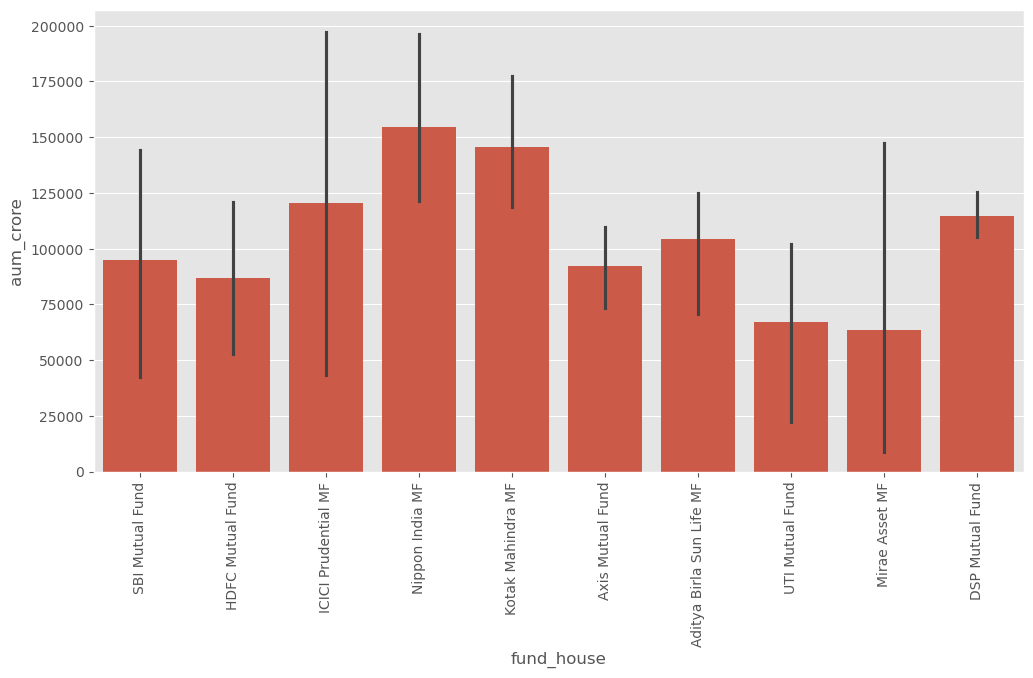

In [4]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=fund,
    x="fund_house",
    y="aum_crore",
    estimator=sum
)

plt.xticks(rotation=90)
plt.show()

In [13]:
sip = txn[txn["transaction_type"]=="SIP"]

monthly = sip.groupby("transaction_month")["amount_inr"].sum().reset_index()

px.line(
    monthly,
    x="transaction_month",
    y="amount_inr",
    title="Monthly SIP Inflow"
)

KeyError: 'transaction_month'

In [14]:
txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [15]:
# Convert transaction_date to datetime
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

# Create a month column
txn["transaction_month"] = txn["transaction_date"].dt.to_period("M").astype(str)

# Filter only SIP transactions
sip = txn[txn["transaction_type"] == "SIP"]

# Monthly SIP inflow
monthly = sip.groupby("transaction_month")["amount_inr"].sum().reset_index()

# Plot
import plotly.express as px

fig = px.line(
    monthly,
    x="transaction_month",
    y="amount_inr",
    title="Monthly SIP Inflow"
)

fig.show()

In [16]:
print(txn["transaction_type"].unique())

['Sip' 'Redemption' 'Lumpsum']


In [20]:
sip = txn[txn["transaction_type"] == "Sip"]
print(sip.shape)
sip.head()

(19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_month
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024-01
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024-01


In [18]:
monthly = sip.groupby("transaction_month")["amount_inr"].sum().reset_index()

print(monthly)

Empty DataFrame
Columns: [transaction_month, amount_inr]
Index: []


In [19]:
print(txn.shape)

(32778, 14)


In [21]:
txn["transaction_type"] = txn["transaction_type"].replace({
    "Sip": "SIP",
    "sip": "SIP",
    "SIP": "SIP",
    "Lumpsum": "Lumpsum",
    "Redemption": "Redemption"
})

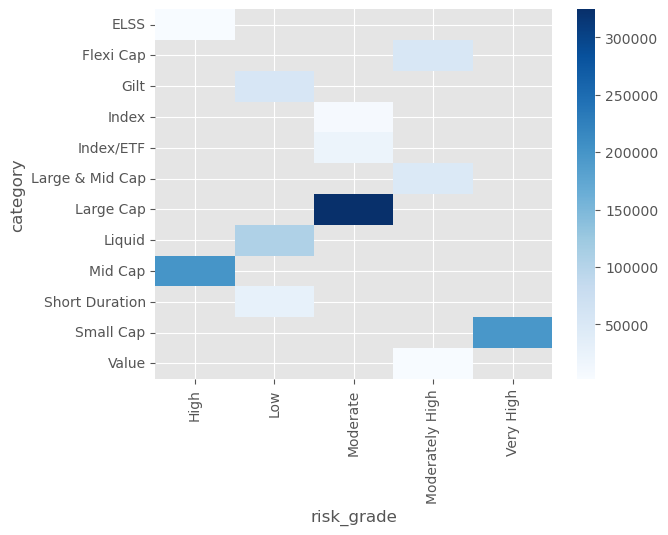

In [22]:
pivot = fund.pivot_table(
    values="aum_crore",
    index="category",
    columns="risk_grade",
    aggfunc="sum"
)

sns.heatmap(pivot,cmap="Blues")
plt.show()

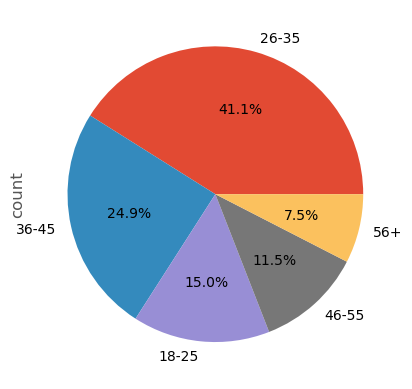

In [23]:
txn["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.show()

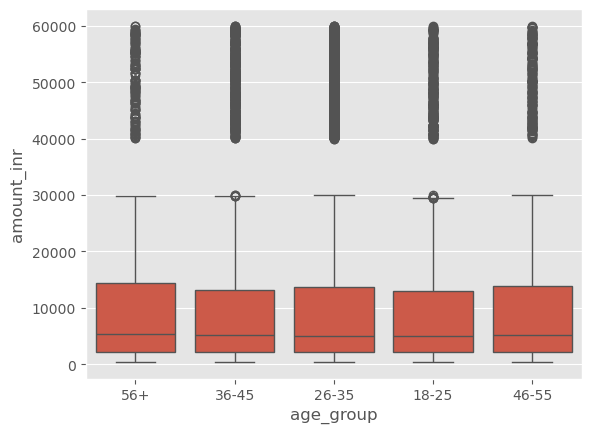

In [24]:
sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr"
)

plt.show()

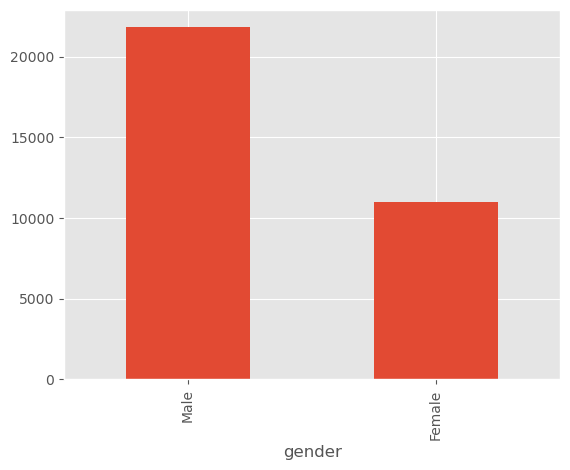

In [25]:
txn["gender"].value_counts().plot.bar()
plt.show()

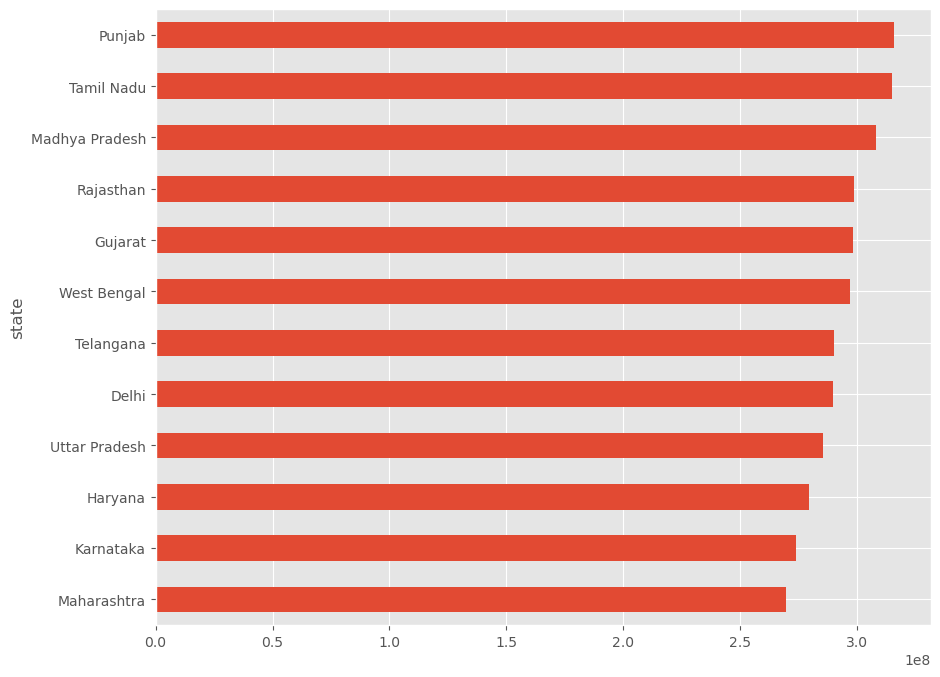

In [26]:
state = txn.groupby("state")["amount_inr"].sum().sort_values()

state.plot.barh(figsize=(10,8))
plt.show()

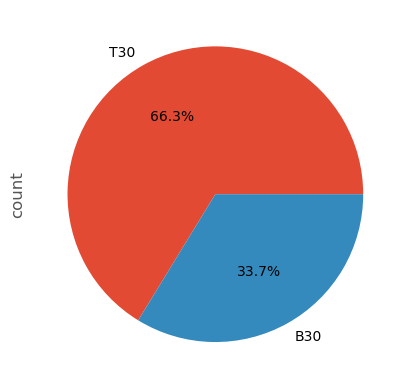

In [27]:
txn["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.show()

In [29]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.head())
print(folio.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


In [30]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


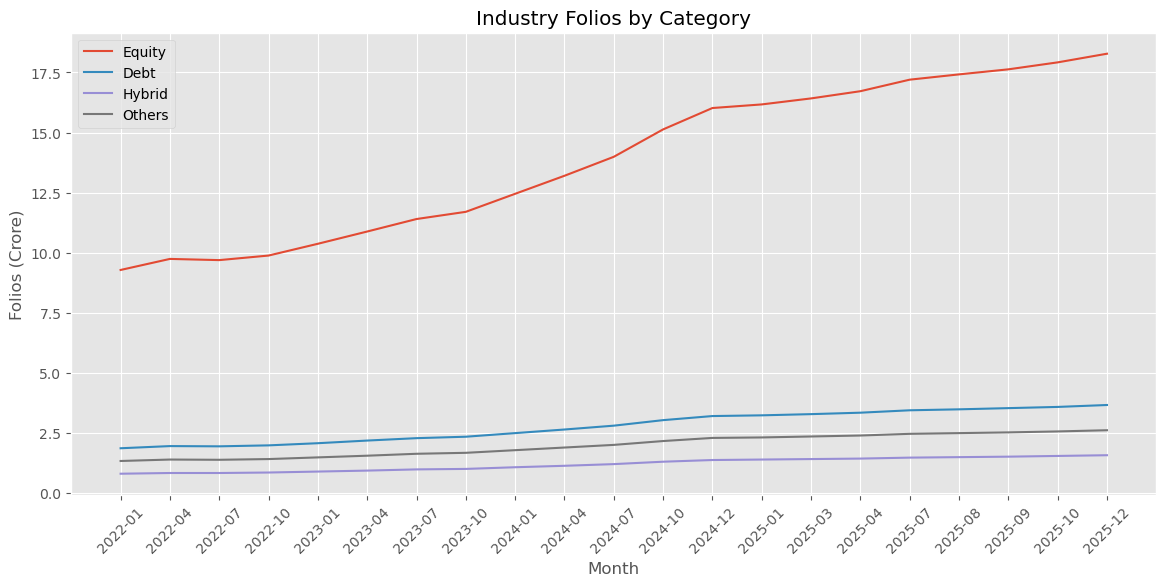

In [33]:
plt.figure(figsize=(14,6))

plt.plot(folio["month"], folio["equity_folios_crore"], label="Equity")
plt.plot(folio["month"], folio["debt_folios_crore"], label="Debt")
plt.plot(folio["month"], folio["hybrid_folios_crore"], label="Hybrid")
plt.plot(folio["month"], folio["others_folios_crore"], label="Others")

plt.title("Industry Folios by Category")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.xticks(rotation=45)
plt.legend()

plt.show()

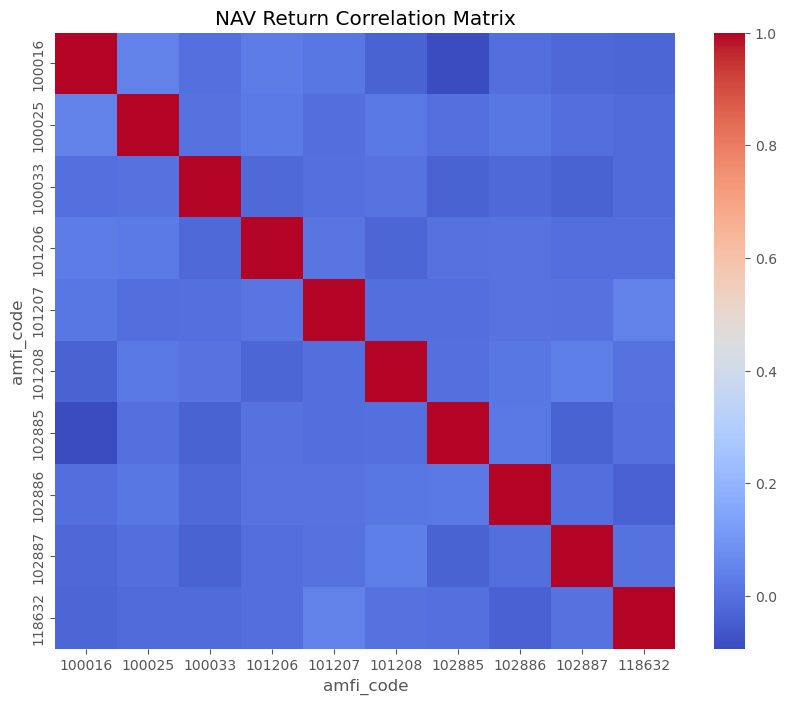

In [34]:
# Pivot NAV data
nav_matrix = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = nav_matrix.pct_change()

# Select first 10 funds
corr = returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [35]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


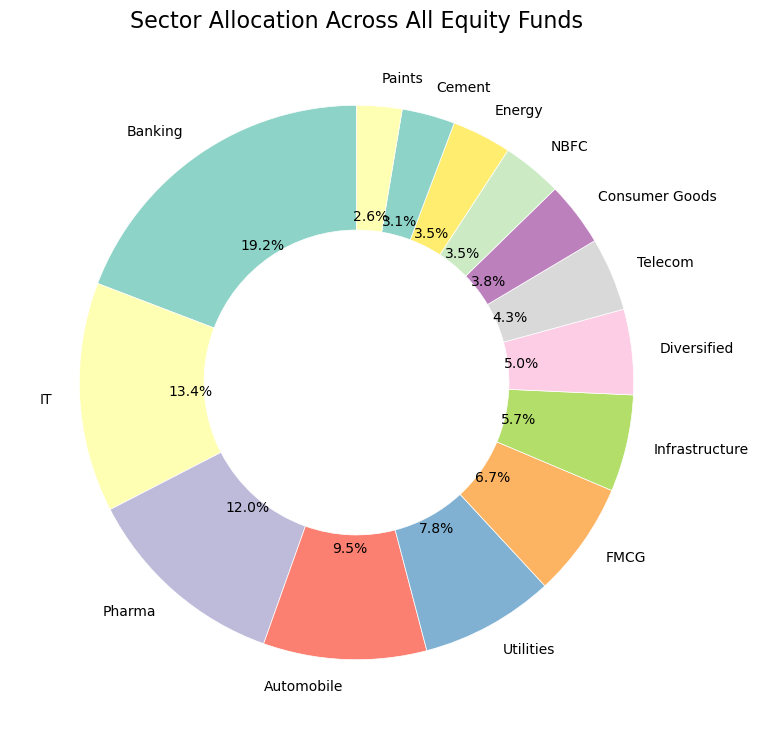

In [36]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

colors = plt.cm.Set3.colors

plt.figure(figsize=(9,9))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title("Sector Allocation Across All Equity Funds", fontsize=16)

plt.show()

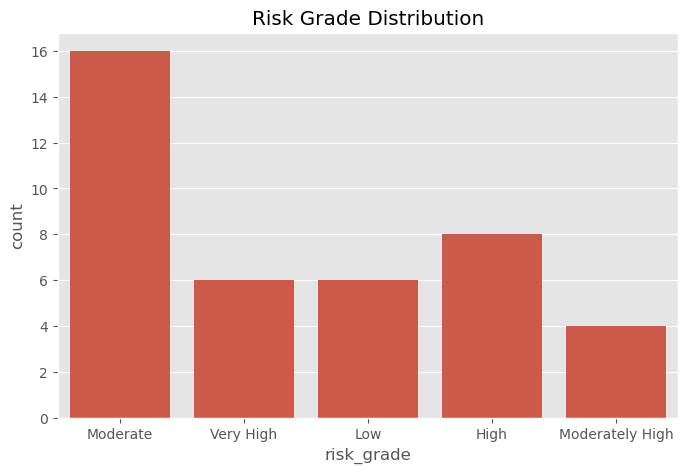

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.show()

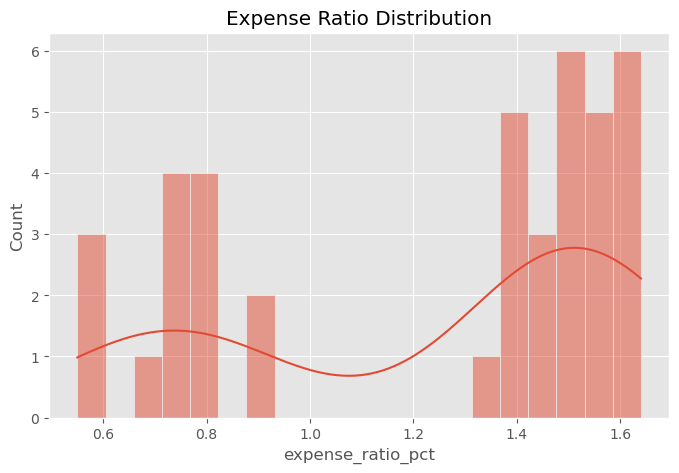

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    fund["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

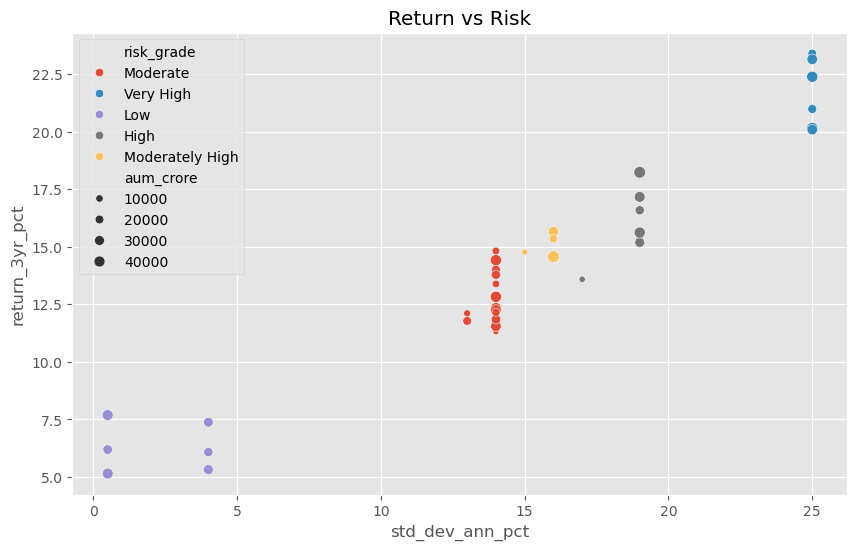

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=fund,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    hue="risk_grade",
    size="aum_crore"
)

plt.title("Return vs Risk")

plt.show()

# Key EDA Findings

### 1.
SBI Mutual Fund manages the highest Assets Under Management among all AMCs.

### 2.
Monthly SIP inflows show a steady upward trend over the study period.

### 3.
Large-cap funds demonstrate relatively stable NAV growth compared to mid-cap and small-cap funds.

### 4.
Most investors belong to the 26–40 years age group.

### 5.
T30 cities contribute a higher share of investments than B30 cities.

### 6.
Expense ratios for most schemes remain below 2%.

### 7.
High-risk funds generally provide higher long-term returns.

### 8.
Most equity funds exhibit strong positive return correlations.

### 9.
Financial Services and Information Technology dominate portfolio allocations.

### 10.
Industry folios have increased consistently, indicating growing mutual fund participation.